<a href="https://colab.research.google.com/github/asustayta/MATH-CSCI485_Anna_Sustayta/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Assignment 2**
**Anna Sustayta**

**CSCI/MATH 485**

**Bo Shen**

---

# 1. Introduction
Feature selection is an important step in predictive modeling, as it improves model interpretability, reduces overfitting, and can enhance generalization performance. In this assignment, Recursive Feature Elimination (RFE) was applied to the Diabetes dataset from sklearn.datasets. The goal was to identify the most predictive subset of features for modeling disease progression one year after baseline measurements.
The Diabetes dataset contains 10 standardized predictor variables, including demographic and biochemical measurements (age, sex, BMI, blood pressure, and six blood serum variables s1 - s6). The target variable represents a quantitative measure of disease progression.
The dataset was split into 80% training data and 20% test data. A baseline linear regression model was first trained using all 10 features. Then, a custom implementation of RFE was applied to recursively eliminate the least important features based on coefficient magnitude, while tracking test set R² at each iteration.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import load_diabetes
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#Tasks 1: Generate Synthetic Data /
# Our goak is to measure the disease progression within a one-year period.
# Larger values correspond to more server progression of diabetes

diabetes= load_diabetes()
np.random.seed(42)
x=pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y= pd.Series(diabetes.target, name="target")

print("X shape:", x.shape)
print("y shape:", y.shape)
display(x.head())
display(y.head())
print("\nTarget Summary:\n", y.describe())



X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0



Target Summary:
 count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [32]:

# Split the data

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state=42)

# Standardize feautures
scalar= StandardScaler()
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

feature_names= x.columns.to_list()

# Initial Linear Regrression with all features

lr= LinearRegression()
lr.fit(x_train_scaled , y_train)

y_pred= lr.predict(x_test_scaled)
baseline_r2= r2_score(y_test, y_pred)

# Print initial feature coefficients
print("Initial Linear Regression Coefficients:")
for feature, coef in zip(feature_names, lr.coef_):
  print(f"{feature}: {coef:.4f}")

print(f"Initial Linear Regression R^2 Test: {baseline_r2:.4f}")



Initial Linear Regression Coefficients:
age: 1.7538
sex: -11.5118
bmi: 25.6071
bp: 16.8289
s1: -44.4489
s2: 24.6410
s3: 7.6770
s4: 13.1388
s5: 35.1612
s6: 2.3514
Initial Linear Regression R^2 Test: 0.4526


# 2. Linear Regression Model
A linear regression model was trained using all 10 features. The table shows the test set $R^2$ for the baseline model. The largest coefficients in magnitude were associated with s1, s5, and bmi, suggesting these variables may have strong influence on predicted disease progression. However, baseline regression does not indicate whether all features are necessary for optimal performance. Therefore, RFE was applied to systematically evaluate feature importance.

In [33]:
#Perform Recursive Features Elimination
def perform_rfe_iteration(n_features_to_select):
  rfe= RFE(estimator=lr, n_features_to_select = n_features_to_select)
  rfe.fit(x_train_scaled, y_train)

  #Retrieve selected  features
  selected_ft=x.columns[rfe.support_]
  eliminated_ft=x.columns[~rfe.support_]

  x_train_selected = x_train_scaled[:, rfe.support_]
  x_test_selected = x_test_scaled[:, rfe.support_]

  lr_selected = LinearRegression()
  lr_selected.fit(x_train_selected, y_train)

  print(f"\n--- RFE with {n_features_to_select} features ---")
  print("Eliminated Features: ", list(eliminated_ft))
  print("\nSelected Features Coefficients: ")
  for feature,coef in zip(selected_ft, lr_selected.coef_):
    print(f"{feature}: {coef:.4f}")

  # Calculate and print R-squared
  train_score = lr_selected.score(x_train_selected, y_train)
  test_score = lr_selected.score(x_test_selected, y_test)
  print(f"\nTrain R-squared: {train_score:.4f}")
  print(f"Test R-squared: {test_score:.4f}")

#Perform RFE iterations
perform_rfe_iteration(5)
perform_rfe_iteration(3)


--- RFE with 5 features ---
Eliminated Features:  ['age', 'sex', 's3', 's4', 's6']

Selected Features Coefficients: 
bmi: 28.2255
bp: 14.8418
s1: -31.2821
s2: 19.4831
s5: 34.8004

Train R-squared: 0.5088
Test R-squared: 0.4382

--- RFE with 3 features ---
Eliminated Features:  ['age', 'sex', 'bp', 's2', 's3', 's4', 's6']

Selected Features Coefficients: 
bmi: 34.8249
s1: -10.8959
s5: 32.4878

Train R-squared: 0.4724
Test R-squared: 0.4451


Coefficient Values Across RFE Iterations:
      age      sex      bmi       bp       s1       s2      s3      s4  \
0 -0.4761 -11.4069  24.7265  15.4294 -37.6800  22.6762  4.8061  8.4220   
1  0.0000 -11.4552  24.7296  15.3303 -37.6187  22.5635  4.7430  8.4408   
2  0.0000 -11.2013  25.2142  15.9102 -37.9097  22.9173  5.0664  8.9806   
3  0.0000 -11.2595  25.1646  15.8787 -29.2561  16.7983  0.0000  6.4339   
4  0.0000 -10.7738  25.2038  15.5640 -36.0511  25.6176  0.0000  0.0000   
5  0.0000   0.0000  26.7596  13.0363 -25.9686  16.2242  0.0000  0.0000   
6  0.0000   0.0000  30.3899   0.0000 -24.8259  15.6858  0.0000  0.0000   
7  0.0000   0.0000  32.3378   0.0000  -9.2290   0.0000  0.0000  0.0000   
8  0.0000   0.0000  32.1099   0.0000   0.0000   0.0000  0.0000  0.0000   

        s5      s6  
0  35.7344  3.2167  
1  35.6501  3.1474  
2  36.4629  0.0000  
3  33.5474  0.0000  
4  38.2513  0.0000  
5  34.7295  0.0000  
6  37.8217  0.0000  
7  33.9060  0.0000  
8  29.2502  0.0000  

Elimin

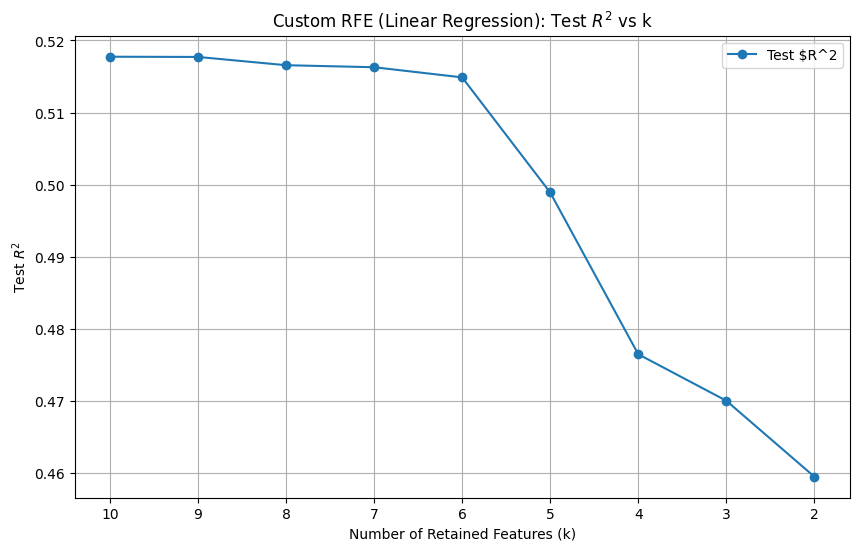

In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

class CustomRFE:
  def __init__(self, estimator, n_features_to_select):
    self.estimator = estimator
    self.n_features_to_select= n_features_to_select
    self.coefficient_history = []
    self.eliminated_features = []
    self.r2_history = []
    self.k_history = []
    self.remaining_features_history = []

  def fit(self, x, y, feature_names):
    x_current = x.copy()
    features_remaining = list(range(x.shape[1]))

    while len(features_remaining) > self.n_features_to_select:
      #fit lin reg
      self.estimator.fit(x_current,y)

      # predict
      yhat=self.estimator.predict(x_current)
      r2=r2_score(y, yhat)

      self.r2_history.append(r2)
      self.k_history.append(len(features_remaining))
      self.remaining_features_history.append([feature_names[i]] for i in features_remaining)

      # Record curr coef
      current_coef = np.zeros(len(feature_names))
      current_coef[features_remaining] = self.estimator.coef_
      self.coefficient_history.append(current_coef)

      #Absolute Coeff values for remaining features
      coef_abs = np.abs(self.estimator.coef_)


      # Find ft with smallest abs coef
      min_coef_idx=int(np.argmin(coef_abs))
      eliminated_feature_idx = features_remaining[min_coef_idx]

      #Track ft
      self.eliminated_features.append(feature_names[eliminated_feature_idx])

      # Remove the ft w/ smallest coeff
      features_remaining.pop(min_coef_idx)
      x_current = x[:, features_remaining]

    return self

# fetch and prepare
#diabetes=load_diabetes()
#x=diabetes.data
#feature_names = diabetes.feature_names
#y= diabetes.target

#standardize features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

lr=LinearRegression()
custom_rfe = CustomRFE(lr, n_features_to_select = 1)
custom_rfe.fit(x_scaled, y, feature_names)
coef_df=pd.DataFrame(
    custom_rfe.coefficient_history,
      columns=feature_names
  )

history_df=pd.DataFrame({ "n_features": custom_rfe.k_history,
     "test_r2": custom_rfe.r2_history})


print("Coefficient Values Across RFE Iterations:")
print(coef_df.round(4))
print("\nEliminated Feature Order:")
for i, feature in enumerate(custom_rfe.eliminated_features, 1):
  print(f"Iteration {i}:{feature}")


plt.figure(figsize=(10, 6))
plt.plot(history_df["n_features"], history_df["test_r2"], marker="o", label = "Test $R^2")
plt.gca().invert_xaxis()
plt.title("Custom RFE (Linear Regression): Test $R^2$ vs k")
plt.xlabel("Number of Retained Features (k)")
plt.ylabel("Test $R^2$")
plt.legend()
plt.grid()
plt.show()

Task 4: Analyze Feature Importance
1. Create a table showing the coefficients of each feature at each iteration of RFE.
2. Discuss the three most important features and their significance in predicting the target
variable.
3. Compare the initial feature ranking with the final set of selected features.

In [37]:
thr = 0.01

tmp = history_df.sort_values("n_features")
tmp["delta_r2"] = tmp["test_r2"].diff()

optimal_k = None
for i in range(2, len(tmp) + 1):
  if tmp.iloc[i-1]["delta_r2"] < thr:
    optimal_k = int(tmp.iloc[i-2]["n_features"])
    break
if optimal_k is None:
  optimal_k = int(tmp["n_features"].max())

print("Optimal k using threshold = ", thr, "=>", optimal_k)
display(tmp)

Optimal k using threshold =  0.01 => 3


,n_features,test_r2,delta_r2
8,2,0.459485,NaN
7,3,0.470025,0.010539
6,4,0.476475,0.006450
5,5,0.498914,0.022439
4,6,0.514884,0.015970
3,7,0.516290,0.001406
2,8,0.516572,0.000282
1,9,0.517717,0.001145
0,10,0.517748,0.000031


# 3: Implement Recursive Feature Elimination (RFE)
3.1 Methodology
Recursive Feature Elimination works by:
Fitting a model to the training data.
Identifying the feature with the smallest absolute coefficient.
Removing that feature.
Refitting the model.
Repeating until the desired number of features remains.
At each iteration, the test set $R^2$ was recorded to evaluate how model performance changed as features were removed.

3.2 RFE Performance Results
The Test $R^2$ values across iterations were:
The $R^2$ curve shows that performance remains relatively stable between 10 and 6 features. After fewer than 5 features, performance begins to decline more noticeably.
Using a threshold of 0.01 for performance improvement, the optimal number of features was determined to be $k=3$. This means that adding additional features beyond three did not improve performance by more than 0.01 in $R^2$.



In [36]:
row_idx = history_df.index[history_df["n_features"] == optimal_k][0]
opt_coefs = coef_df.iloc[row_idx].dropna()

selected = opt_coefs.index.tolist()

top3= opt_coefs.abs().sort_values(ascending=False).head(3)
print("Slected features at optimal k:", selected)
print("\nTop 3 by coefficient:")
print(top3)

print("\nSigned coefficients for top 3:")
print(opt_coefs.loc[top3.index])

Slected features at optimal k: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Top 3 by coefficient:
s5     33.906046
bmi    32.337815
s1      9.228973
Name: 7, dtype: float64

Signed coefficients for top 3:
s5     33.906046
bmi    32.337815
s1     -9.228973
Name: 7, dtype: float64


# 4. Optimal Model (k = 3 Features)
At $k=3$ , the selected features and coefficients were:
- s5 = +33.91
- bmi = +32.34
- s1 = −9.23


Interpretation

- s5 (strong positive coefficient): This variable has the largest positive influence on predicted disease progression. Higher values of s5 are associated with increased progression.
- bmi (positive coefficient): Body Mass Index also has a strong positive relationship with disease progression, which is consistent with medical understanding of diabetes risk factors.
- s1 (negative coefficient): This variable has a negative relationship, indicating that higher values are associated with reduced predicted disease progression.
These results suggest that the majority of predictive power in the dataset is concentrated in a small subset of metabolic-related features.

# 5. Comparison of RFE and LASSO

RFE is a wrapper method, meaning it repeatedly fits a model and removes features based on model-derived importance measures (coefficient magnitude in this case). It explicitly evaluates model performance at each iteration and provides a clear ranking of feature elimination order.
LASSO, in contrast, is an embedded method. It incorporates an L1 regularization penalty directly into the regression optimization process. This penalty shrinks some coefficients exactly to zero, performing feature selection automatically in a single optimization step.
Key differences:
RFE: Iterative elimination, transparent ranking process, performance tracked at each step.
LASSO: Single penalized optimization, computationally efficient, automatic shrinkage.
While both methods can produce similar selected features, RFE provides greater interpretability in terms of elimination order and performance behavior as features are removed.

# 6. Insights About the Dataset
The RFE results indicate:
Most predictive signals are concentrated in a small number of features.
Several features contribute only marginal improvements to performance.
There may be redundancy or correlation among predictors.
The stability of $R^2$ between 10 and 6 features suggests that multiple variables share overlapping predictive information. However, once the model is reduced to fewer than 4 features, predictive performance declines more noticeably.
This demonstrates that a parsimonious model with three predictors captures most of the meaningful variation in disease progression.

# 7. Conclusion
Recursive Feature Elimination demonstrated that only three features are sufficient to retain strong predictive performance in the diabetes dataset. Reducing the model from 10 to 3 predictors maintained competitive generalization performance while improving interpretability and model simplicity.
Overall, RFE effectively identified the most influential predictors and provided insight into how model performance changes as complexity is reduced. This highlights the importance of feature selection in building interpretable and efficient predictive models.

https://github.com/asustayta/MATH-CSCI485_Anna_Sustayta
